In [1]:
from dune_client.client import DuneClient

In [2]:
dune = DuneClient("2s0qN4qSOx8KJhuC0jaD1HlztWyN69fa")
query_result = dune.get_latest_result(4932533)

In [5]:
query_result.get_rows().__len__()

135

In [6]:
135/3*2500

112500.0

# dune analytics

In [2]:
import pandas as pd

In [18]:
nt = pd.read_csv('new_tokens.csv')
print(nt.columns.to_list())
nt.groupby('project').sum().drop('cum_sum', axis=1)

['month_', 'project', 'cum_sum', 'token_cnt']


C:\Users\Димас\AppData\Local\Temp\ipykernel_17516\1779378293.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  nt.groupby('project').sum().drop('cum_sum', axis=1)


,token_cnt
project,
dedust,33833
gaspump,25587
megaton,38
ston.fi,20614
ton.fun,351482
tonco,69


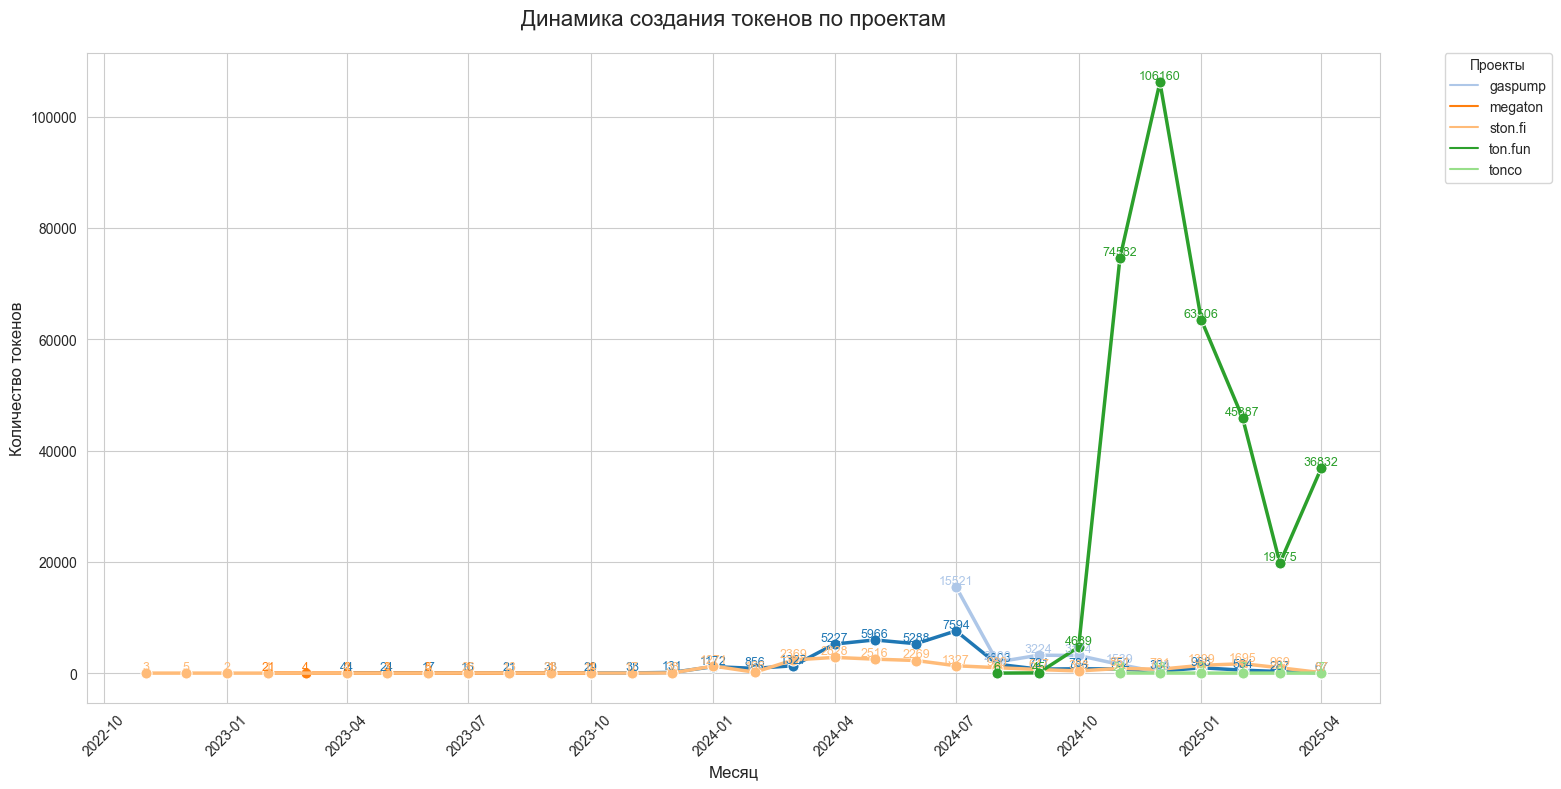

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем временную ось из месяца
nt['month_'] = pd.to_datetime(nt['month_'])

# Сортируем данные по проектам и месяцам
df_sorted = nt.sort_values(['project', 'month_'])

# Создаем фигуру с настроенным размером
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Строим линейные графики для каждого проекта
ax = sns.lineplot(
    data=df_sorted,
    x='month_', 
    y='token_cnt',  # Можно заменить на 'cum_sum' для отображения накопленной суммы
    hue='project',
    palette='tab20',  # Используем палитру для 20 различных цветов
    linewidth=2.5,
    marker='o',
    markersize=8
)

# Настройка оформления
plt.title('Динамика создания токенов по проектам', fontsize=16, pad=20)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество токенов', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Улучшаем отображение легенды
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    title='Проекты',
    handles=handles[1:],  # Исключаем автоматическую легенду
    labels=labels[1:],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

# Добавляем подписи данных
for line in ax.lines:
    for x,y in zip(line.get_xdata(), line.get_ydata()):
        if y > 0:  # Показываем метки только для ненулевых значений
            ax.text(
                x, y+5, 
                f'{int(y)}', 
                color=line.get_color(),
                ha='center', 
                va='bottom',
                fontsize=9
            )

plt.show()
